In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1.Atmosphere Erosion
## 1.1 Planetesimal impacts

### Assumptions

1. Constant density of impactor.
2. Sphere impactor.
3. For the target: (R/R_E)=(M/M_E)^0.27 (ref needed)
4. Scale height calculated by surface gravity. (?)

### 1.1.1The planetesimal impact properties

|property|--------symbol---------|
|:---|:---:|
|size|$D$|
|density| $\rho_{imp}$|
|velocity|$v_{imp}$|
|mass| $m_{imp}=\frac{\pi}{6}\rho_{imp}D^3$|

In [ ]:
class Impactor_small:
  def __init__(self, m_imp, rho_imp,v_imp,b):
    self.D = pow(6*m_imp/rho_imp/np.pi,1/3)
    self.rho = rho_imp
    self.m = m_imp
    self.v = v_imp

### 1.1.2 The target properties

|property|--------symbol--------|
|:-|:-:|
|Radius|$R_p$|
|Mass|$M_p$|
|density|$\rho_p$|
|gravity|$g$|
|mean molecular weight|$\mu$|
|Atmospheric density|$\rho_{atm}$|
|Atmosphere Temperature|$T_{atm}$|
|Escape Velocity|$v_{esp} = \sqrt{\frac{2GM}{R}}$|
|Atmospheric scale height|$H = \frac{k_B T}{\mu m_Hg}$|
|Atmosphere Mass|$m_{atm} = 4\pi R_p^2H\rho_{atm}$| 


**What's the starting time of the atmosphere escape? Can we use the stmospheric mass estimate?**

In [ ]:
class Planet:
  def __init__(self,Mp,mu,rho_atm,T_atm):
    G = 6.67e-11
    kb = 1.38e-23
    m_H= 1.674e-27
    R_E = 6.378e6
    M_E = 5.972e24
    Rp = R_E*pow(Mp/M_E,0.27)
    g = G*Mp/Rp**2
    H = kb*T_atm/(mu*m_H*g) #scale hight
    
    self.R = Rp
    self.M = Mp
    self.rho = Mp/(4/3*np.pi*Rp**3)
    self.g = g
    self.mmw = mu
    self.rho_atm = rho_atm
    self.T_atm = T_atm
    self.v_esp = np.sqrt(2*G*Mp/Rp)
    self.H = kb*T_atm/(mu*m_H*g) 
    self.m_atm = (4/3*np.pi*(Rp+H)**3-4/3*np.pi*(Rp)**3)*rho_atm
    self.V = 4/3*np.pi*Rp**2


In [ ]:
def m_atm_loss_small_imp_scale(Impactor,Planet):
    eta = (Impactor.D/Planet.H)**3*(
        (Impactor.v/Planet.v_esp)**2-1)*(
        Impactor.rho*Planet.rho/(Planet.rho_atm*(Impactor.rho+Planet.rho)))

    log_eta = np.log10(eta)
    Ka_eta = np.copy(eta)
    Ka_eta[eta>1e6] = 10**(-0.6438*eta[eta>1e6]+0.4746)
    Ka_eta[eta<=1e6] = 10**(-6.375+5.239*log_eta[eta<=1e6]
                            -2.121*log_eta[eta<=1e6]**2
                            +0.397*log_eta[eta<=1e6]**3
                            -0.037*log_eta[eta<=1e6]**4
                            +0.0013*log_eta[eta<=1e6]**5)
    m_atm_loss = Ka_eta*((Impactor.v/Planet.v_esp)**2-1)
    m_max = 2*np.pi*Planet.rho_atm*Planet.H**2*Planet.R/Impactor.m
    m_atm_loss[m_atm_loss>m_max] = m_max[m_atm_loss>m_max] 
    return m_atm_loss


def m_atm_loss_small_imp(Impactor,Planet):
    eta = (Impactor.D/Planet.H)**3*(
        (Impactor.v/Planet.v_esp)**2-1)*(
        Impactor.rho*Planet.rho/(Planet.rho_atm*(Impactor.rho+Planet.rho)))

    log_eta = np.log10(eta)
    Ka_eta = np.copy(eta)
    Ka_eta[eta>1e6] = 10**(-0.6438*eta[eta>1e6]+0.4746)
    Ka_eta[eta<=1e6] = 10**(-6.375+5.239*log_eta[eta<=1e6]
                            -2.121*log_eta[eta<=1e6]**2
                            +0.397*log_eta[eta<=1e6]**3
                            -0.037*log_eta[eta<=1e6]**4
                            +0.0013*log_eta[eta<=1e6]**5)
    m_atm_loss = Ka_eta*((Impactor.v/Planet.v_esp)**2-1)*Impactor.m
#     m_max = 2*np.pi*Planet.rho_atm*Planet.H**2*Planet.R
#     m_atm_loss[m_atm_loss>m_max] = m_max[m_atm_loss>m_max] 
    return m_atm_loss


    
def m_atm_loss_small_imp_single(Impactor,Planet):
    eta = (Impactor.D/Planet.H)**3*(
        (Impactor.v/Planet.v_esp)**2-1)*(
        Impactor.rho*Planet.rho/(Planet.rho_atm*(Impactor.rho+Planet.rho)))

    log_eta = np.log10(eta)
    Ka_eta = np.copy(eta)
    Ka_eta[eta>1e6] = 10**(-0.6438*eta[eta>1e6]+0.4746)
    Ka_eta[eta<=1e6] = 10**(-6.375+5.239*log_eta[eta<=1e6]
                            -2.121*log_eta[eta<=1e6]**2
                            +0.397*log_eta[eta<=1e6]**3
                            -0.037*log_eta[eta<=1e6]**4
                            +0.0013*log_eta[eta<=1e6]**5)
    m_atm_loss = Ka_eta*((Impactor.v/Planet.v_esp)**2-1)*Impactor.m
    m_max = 2*np.pi*Planet.rho_atm*Planet.H**2*Planet.R
    m_atm_loss = np.min([m_max,m_atm_loss])
    return m_atm_loss
    
    

In [ ]:
Pl = Planet(5.972e24,28.97,1.2,300)

m_imp = np.logspace(7,17)
v_imp = np.linspace(1,7)

m_imp_m,v_imp_m = np.meshgrid(m_imp,v_imp)


Im = Impactor_small(m_imp_m,3*1000,v_imp_m*Pl.v_esp,0)
m_atm_loss = m_atm_loss_small_imp_scale(Im,Pl)

/software/python-anaconda-2020.02-el7-x86_64/lib/python3.7/site-packages/ipykernel_launcher.py:6: RuntimeWarning: divide by zero encountered in log10
  


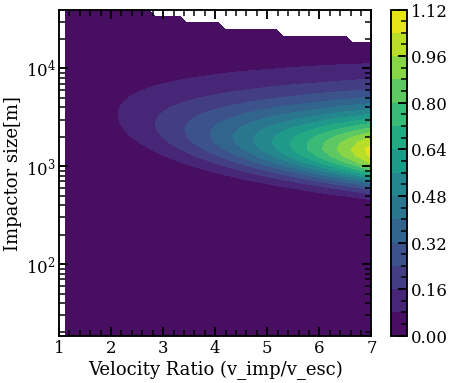

In [ ]:
from matplotlib.colors import LogNorm
from matplotlib import ticker, cm

plt.style.use(['science','no-latex'])
sns.set_context('talk')

fig=plt.figure(figsize=(7,6))


z = np.ma.masked_where(m_atm_loss <= 0, m_atm_loss)

n_levels=15
plt.contourf(v_imp_m,Im.D,z, n_levels)


plt.yscale('log')
plt.xlabel('Velocity Ratio (v_imp/v_esc)')
plt.ylabel('Impactor size[m]')


plt.colorbar()


Text(0, 0.5, 'Normalized Distribution')

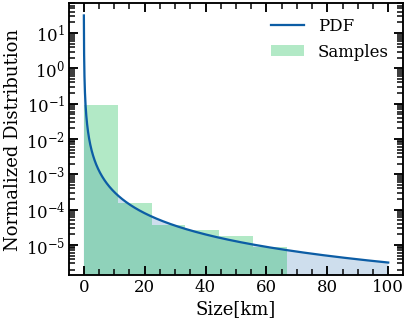

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig=plt.figure(figsize=(6,5))

lower_l = pow(10,-1.5)
upper_l = 100
xs = np.linspace(lower_l, upper_l, 10000)
pdfs = 1/(1/lower_l-1/upper_l)*xs**(-2)

from scipy.interpolate import interp1d
from scipy.integrate import cumtrapz
def get_inverted_cdf(xs, pdfs):
    cdfs = cumtrapz(pdfs, x=xs) # Get the CDF using a very fast trapz rule
    cdfs = cdfs / cdfs.max()  # Ensure its normalised, to cater for unnormalised PDFs
    cdfs = np.insert(cdfs, 0, 0)  # Add the 0 area to start of the CDF array
    return interp1d(cdfs, xs, kind='linear')  # return interpolation from cdf -> x
def sample_fn(fn, n=1):
    return fn(np.random.random(size=n))


fn = get_inverted_cdf(xs, pdfs)
samples_2 = sample_fn(fn, n=10000)

HIST_BINS = np.linspace(lower_l, upper_l, 10)
plt.plot(xs, pdfs, label='PDF')
plt.fill_between(xs, pdfs, 0, alpha=0.2)
plt.hist(samples_2, HIST_BINS, density=1, alpha=0.3, label='Samples')
plt.legend(), plt.xlabel('Size[km]');
plt.yscale('log')
plt.ylabel('Normalized Distribution')

$$\frac{dN}{dD} = kD^{-2}$$
To solve for $k$:
$$\int_{D_{min}}^{D_{max}}\frac{dN}{dD}\frac{\pi}{6}\rho D^3 dD = M_{tot}$$
$$\int_{D_{min}}^{D_{max}}\frac{dN}{dD}D^3dD = \frac{6M_{tot}}{\pi \rho}$$
$$\int_{D_{min}}^{D_{max}}kDdD = \frac{6M_{tot}}{\pi \rho}$$
$$k = \frac{12M_{tot}}{\pi \rho(D_{max}^2-D_{min}^2)}$$
Then,
$$N = \int_{D_{min}}^{D_{max}}kD^{-2}dD = k(\frac{1}{D_{min}}-\frac{1}{D_{max}})$$



In [ ]:
def M_D_dist(M_tot,rho_imp):
    from scipy.interpolate import interp1d
    from scipy.integrate import cumtrapz
    import random
    def get_inverted_cdf(xs, pdfs):
        cdfs = cumtrapz(pdfs, x=xs) # Get the CDF using a very fast trapz rule
        cdfs = cdfs / cdfs.max()  # Ensure its normalised, to cater for unnormalised PDFs
        cdfs = np.insert(cdfs, 0, 0)  # Add the 0 area to start of the CDF array
        return interp1d(cdfs, xs, kind='linear')  # return interpolation from cdf -> x
    def sample_fn(fn, n=1):
        return fn(np.random.random(size=n))
    
    lower_l = pow(10,-1.5)
    upper_l = 100
    xs = np.linspace(lower_l, upper_l, 10000)
    pdfs = 1/(1/lower_l-1/upper_l)*xs**(-2)
    fn = get_inverted_cdf(xs, pdfs)
    
    N=int(12*M_tot/1e9/(np.pi*rho_imp*(upper_l**2-lower_l**2))*(1/lower_l-1/upper_l))
    samples = sample_fn(fn, n=N)
    M_tot_cal = np.sum(1/6*np.pi*samples**3*rho_imp)*1e9
    while np.abs(M_tot-M_tot_cal)>1e-4*M_tot:
        if M_tot>M_tot_cal:
            samples_2 = sample_fn(fn, n=100)
            M_tot_cal = np.sum(1/6*np.pi*samples_2**3*rho_imp)*1e9+M_tot_cal
            samples = np.append(samples_2,samples)
#             print(M_tot-M_tot_cal)
        else:
            N = len(samples)-1
#             print(M_tot-M_tot_cal)
            idx = np.array([random.randint(0, N) for p in range(0, 100)])
            samples = np.delete(samples,idx)
            M_tot_cal = np.sum(1/6*np.pi*samples**3*rho_imp)*1e9
    return samples,M_tot_cal


In [ ]:
rho_imp=3200
M_tot=1e20

sample_test,M_tot_cal = M_D_dist(M_tot,rho_imp)




In [ ]:

dens_atm = 1.2
Pl = Planet(5.972e24,28.97,dens_atm,300)

m_imp = (sample_test*1e3)**3/6*rho_imp*np.pi
v_imp = 1.2

Im = Impactor_small(m_imp,3*1000,v_imp*Pl.v_esp,0)
m_atm_loss = m_atm_loss_small_imp(Im,Pl)


/software/python-anaconda-2020.02-el7-x86_64/lib/python3.7/site-packages/ipykernel_launcher.py:23: RuntimeWarning: divide by zero encountered in log10


Text(-8, 115, 'Total Loss = 0.015M_atm')

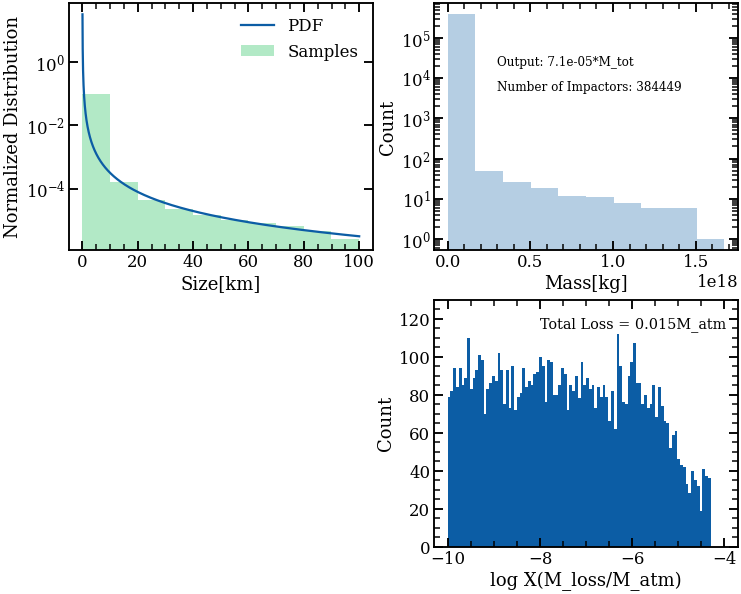

In [ ]:
fig=plt.figure(figsize=(12,10))

ax1 = fig.add_subplot(221)
plt.plot(xs, pdfs, label='PDF')
plt.hist(sample_test, density=1, alpha=0.3, label='Samples')

plt.legend(), plt.xlabel('Size[km]');
plt.yscale('log')
plt.ylabel('Normalized Distribution')

ax1 = fig.add_subplot(222)
plt.hist((sample_test*1e3)**3/6*rho_imp*np.pi, alpha=0.3)
plt.text(3e17,2e4,'Output: %2.1e*M_tot'%(np.abs(M_tot-M_tot_cal)/M_tot),fontsize='large')
plt.text(3e17,5e3,'Number of Impactors: %d'%(len(sample_test)),fontsize='large')

plt.xlabel('Mass[kg]');
plt.yscale('log')
plt.ylabel('Count')

ax1 = fig.add_subplot(224)

m_atm_loss_mask = np.ma.masked_where(m_atm_loss <= 0, m_atm_loss)
plt.hist(np.log10(m_atm_loss_mask/Pl.m_atm),cumulative=False,bins=100,range=(-10,-4))
plt.xlabel('log X(M_loss/M_atm)')
plt.ylabel('Count')
plt.ylim(0,130)
plt.text(-8,115,'Total Loss = %.3fM_atm'%(np.sum(m_atm_loss_mask)/Pl.m_atm),fontsize='x-large')

Text(1000000000.0, 4e-05, 'Total Loss: 0.0051 M_atm')

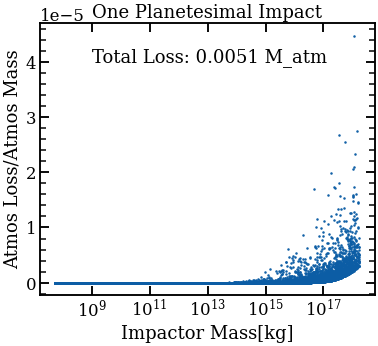

In [ ]:
fig=plt.figure(figsize=(6,5))
plt.scatter(m_imp,m_atm_loss/Pl.m_atm,s=1)
plt.xscale('log')
# plt.yscale('log')
plt.xlabel('Impactor Mass[kg]')
plt.ylabel('Atmos Loss/Atmos Mass')
total_loss = np.sum(m_atm_loss/Pl.m_atm)
plt.title('One Planetesimal Impact')
plt.text(1e9,4e-5,'Total Loss: %.4f M_atm'%(total_loss))
# plt.ylim(1e-20,1)

In [ ]:
dens_atm_1 = 1
dens_atm_2 = 1000

Pl_1 = Planet(5.972e24,28.97,dens_atm_1,300)
Pl_2 = Planet(5.972e24,28.97,dens_atm_2,300)

m_imp = (sample_test*1e3)**3/6*rho_imp*np.pi
v_imp = 1.2

Im = Impactor_small(m_imp,3*1000,v_imp*Pl.v_esp,0)

m_atm_loss_1 = m_atm_loss_small_imp(Im,Pl_1)
m_atm_loss_2 = m_atm_loss_small_imp(Im,Pl_2)

(1e-20, 1)

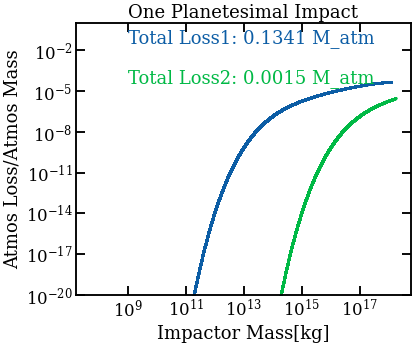

In [ ]:
fig=plt.figure(figsize=(6,5))

plt.scatter(m_imp,m_atm_loss_1/Pl_1.m_atm,s=1,label='atm_dens =1')
plt.scatter(m_imp,m_atm_loss_2/Pl_2.m_atm,s=1,label='atm_dens =1000')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Impactor Mass[kg]')
plt.ylabel('Atmos Loss/Atmos Mass')
total_loss_1 = np.sum(m_atm_loss_1/Pl_1.m_atm)
total_loss_2 = np.sum(m_atm_loss_2/Pl_2.m_atm)
plt.title('One Planetesimal Impact')
plt.text(1e9,4e-2,'Total Loss1: %.4f M_atm'%(total_loss_1),c='C0')
plt.text(1e9,4e-5,'Total Loss2: %.4f M_atm'%(total_loss_2),c='C1')
# plt.legend()
plt.ylim(1e-20,1)

In [ ]:
# %%time
# N_random = 1000

# M_E = 5.972e24 
# atmos_loss_dist = np.zeros(N_sample)
# Total_mass =  1.38e-4*M_E #1.38e-4, 1.67e-4, and 2.5e-3
# target_mass = 5.972e24
# MMW_atmos = 30
# rho_imp=3300
# density_i = 10
# v_imp = 1.2

# Pl = Planet(target_mass,MMW_atmos,density_i,300)

# for n in range(N_random):
#     sample_test = M_D_dist(Total_mass,rho_imp)[0]
#     m_imp = (sample_test*1e3)**3/6*rho_imp*np.pi
#     for m_imp_i in m_imp:
#         Im = Impactor_small(m_imp_i,rho_imp,v_imp*Pl.v_esp,0)
#         m_atm_loss = m_atm_loss_small_imp_single(Im,Pl)
#         atmos_loss_dist[n] += m_atm_loss

#         Pl.m_atm = Pl.m_atm -m_atm_loss
#         Pl.rho_atm = Pl.m_atm/((4/3*np.pi*(Pl.R+Pl.H)**3-4/3*np.pi*(Pl.R)**3))
    

In [ ]:

# fig=plt.figure(figsize=(6,5))

# m_atm_loss_mask = np.ma.masked_where(m_atm_loss_dist <= 0.1, m_atm_loss_dist)

# plt.hist(np.log10(m_atm_loss_mask))

# plt.xlabel('log Mass[kg]');
# plt.yscale('log')
# plt.ylabel('Count')
# plt.title('Planetesimal Atmospheric Erosion')

## 1.2 Giant impacts

### Assumptions:

1. Scaled R-M relation for giant impactors: (R/R_E)=(M/M_E)^0.27 (ref needed)


### 1.2.1 Giant impacts properties

|property|--------symbol---------|
|:---|:---:|
|radius|$R_i$|
|bulk density ratio| $\rho_{imp}$|
|velocity|$v_{imp}$|
|mass| $m_{imp}=\frac{\pi}{6}\rho_{imp}D^3$|
|impact parameter|$b = \sin{(\beta)}$|

In [ ]:
class Impactor_giant:
  def __init__(self, M_imp, v_imp,b):
    R_E = 6.378e6
    M_E = 5.972e24
    R_imp = R_E*pow(M_imp/M_E,0.27)
    self.Ri = R_imp
    self.Mi = M_imp
    self.rho = M_imp/(4/3*np.pi*R_imp**3)
    self.v = v_imp
    self.b = b
    self.Vi = 4/3*np.pi*R_imp**2

In [ ]:
def m_atm_loss_giant_imp(Impactor,Planet):
    d = (Planet.R-Impactor.Ri)*(1-Impactor.b)
    V_cap_i =np.pi/3*d**2*(3*Impactor.Ri-d)
    V_cap_t =np.pi/3*d**2*(3*Planet.R-d)
    f_M = (Planet.rho*V_cap_t+Impactor.rho*V_cap_i)/(Planet.rho*Planet.V+Impactor.rho*Impactor.Vi)
    ratio = 0.64*pow((Impactor.v/Planet.v_esp)**2
                  *np.sqrt(Impactor.Mi/(Impactor.Mi+Planet.M))
                 *np.sqrt(Impactor.rho/Planet.rho)*f_M,0.65)
    return ratio
    
    

In [ ]:
M_E = 5.972e24
M_imp = np.linspace(0,1)
V_imp = np.linspace(0,7)

Im = Impactor_giant(M_imp*M_E,V_imp*Pl.v_esp,0)
m_atm_loss_giant = m_atm_loss_giant_imp(Im,Pl)

/software/python-anaconda-2020.02-el7-x86_64/lib/python3.7/site-packages/ipykernel_launcher.py:8: RuntimeWarning: invalid value encountered in true_divide
  


Text(0.5, 1.0, 'Giant Atmospheric Erosion')

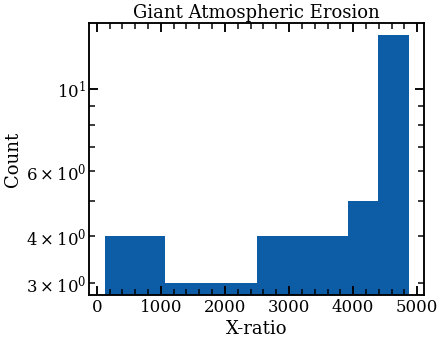

In [ ]:
fig=plt.figure(figsize=(6,5))

m_atm_loss_giant_mask = np.ma.masked_where(m_atm_loss_giant <= 0, m_atm_loss_giant)

plt.hist(m_atm_loss_giant_mask)

plt.xlabel('X-ratio');
plt.yscale('log')
plt.ylabel('Count')
plt.title('Giant Atmospheric Erosion')